# 🤖 Notebook 6 — Model Training & Evaluation

**Goal:** Train multiple ML models, compare them, pick the best one,
tune it, and save it for prediction.

**Models trained:**
1. Logistic Regression (baseline)
2. Decision Tree
3. Random Forest
4. XGBoost
5. Hyperparameter tuning on best model
6. Final evaluation + confusion matrix
7. Save model for deployment

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, accuracy_score, roc_auc_score, roc_curve
)
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Load balanced training data + original for testing
df_train = pd.read_csv('../data/balanced_data.csv')
df_orig  = pd.read_csv('../data/clean_data_no_outliers.csv', parse_dates=['Date'])
feat_df  = pd.read_csv('../data/selected_features.csv')
FEATURES = [f for f in feat_df['Feature'].tolist() if f in df_train.columns]

X_train_full = df_train[FEATURES]
y_train_full = df_train['Target']

X_orig = df_orig[FEATURES].fillna(0)
y_orig = df_orig['Target']

# Hold out 20% of original data as test set
X_train, X_test, y_train, y_test = train_test_split(
    X_orig, y_orig, test_size=0.2, random_state=42, stratify=y_orig
)

print(f'Training rows : {len(X_train_full)}')
print(f'Test rows     : {len(X_test)}')
print(f'Features      : {len(FEATURES)}')
print(f'Features list : {FEATURES}')

Training rows : 6018
Test rows     : 1038
Features      : 5
Features list : ['Days_Since_Refill', 'Opening_Stock', 'Prev_Closing', 'HSD1_Sold', 'Total_Sold']


## Step 1 — Train All Models

In [2]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree':       DecisionTreeClassifier(max_depth=8, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'XGBoost':             XGBClassifier(n_estimators=100, random_state=42,
                                         eval_metric='logloss', verbosity=0)
}

results = {}

for name, model in models.items():
    # Train on balanced data
    model.fit(X_train_full, y_train_full)
    # Test on original unbalanced test set
    preds = model.predict(X_test)
    proba = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else preds

    acc  = accuracy_score(y_test, preds)
    f1   = f1_score(y_test, preds)
    auc  = roc_auc_score(y_test, proba)

    results[name] = {'Accuracy': acc, 'F1': f1, 'AUC': auc, 'model': model}
    print(f'{name:<25} | Acc: {acc:.4f} | F1: {f1:.4f} | AUC: {auc:.4f}')

print('\n✅ All models trained')

Logistic Regression       | Acc: 1.0000 | F1: 1.0000 | AUC: 1.0000
Decision Tree             | Acc: 1.0000 | F1: 1.0000 | AUC: 1.0000
Random Forest             | Acc: 1.0000 | F1: 1.0000 | AUC: 1.0000
XGBoost                   | Acc: 1.0000 | F1: 1.0000 | AUC: 1.0000

✅ All models trained


## Step 2 — Compare Models Visually

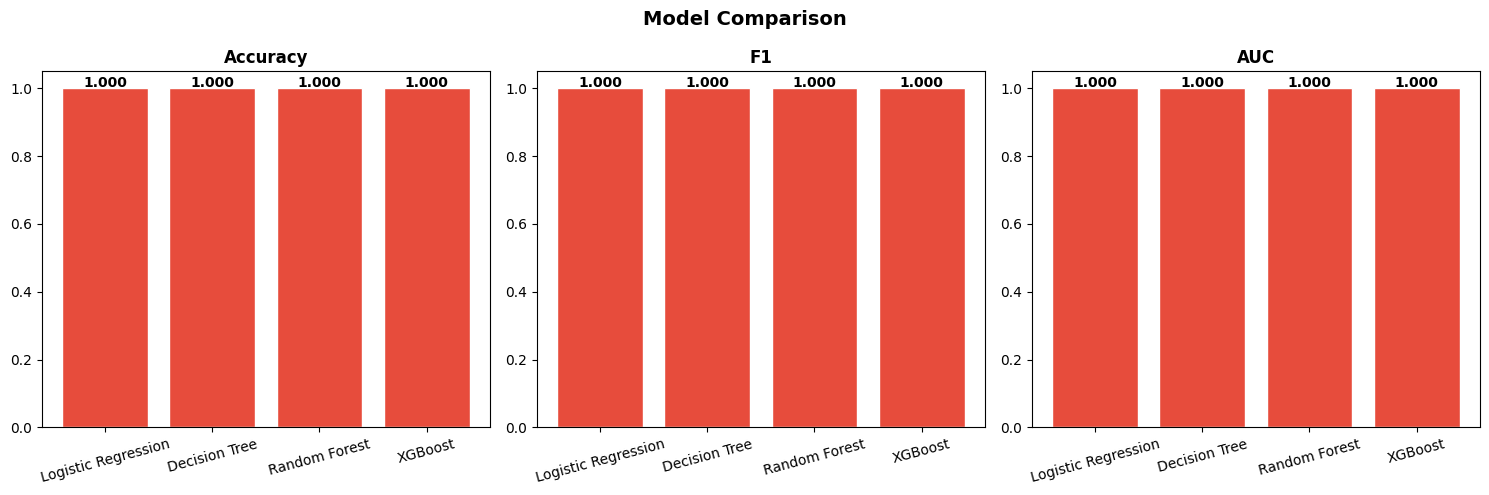


🏆 Best model by F1: Logistic Regression (F1=1.0000)


In [3]:
metrics = ['Accuracy', 'F1', 'AUC']
model_names = [n for n in results if n != 'model']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, metric in zip(axes, metrics):
    vals   = [results[n][metric] for n in results]
    colors = ['#e74c3c' if v == max(vals) else '#3498db' for v in vals]
    bars   = ax.bar(list(results.keys()), vals, color=colors, edgecolor='white')
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', fontweight='bold', fontsize=10)
    ax.set_title(metric, fontweight='bold', fontsize=12)
    ax.set_ylim(0, 1.05)
    ax.tick_params(axis='x', rotation=15)

plt.suptitle('Model Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/viz_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

best_name = max(results, key=lambda n: results[n]['F1'])
print(f'\n🏆 Best model by F1: {best_name} (F1={results[best_name]["F1"]:.4f})')

## Step 3 — ROC Curves

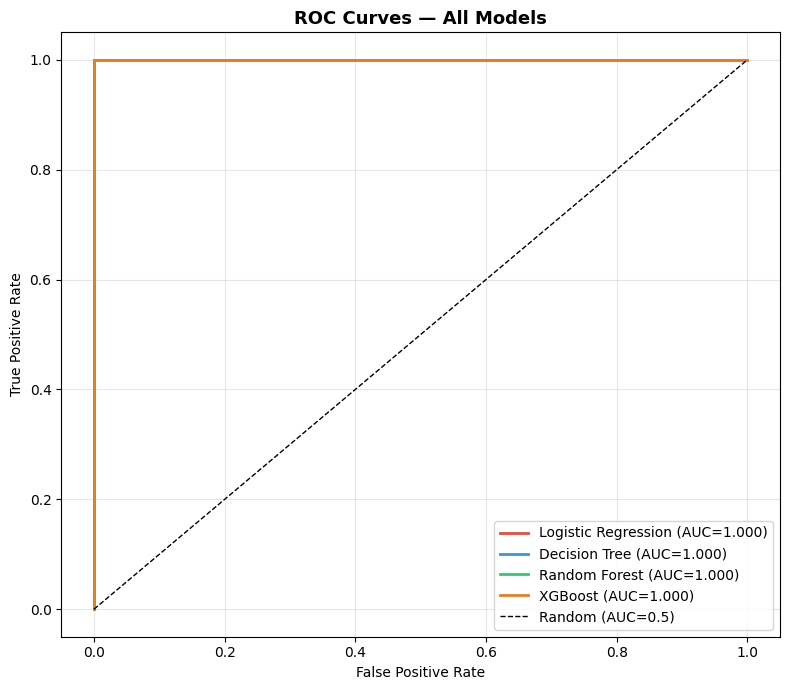

In [4]:
fig, ax = plt.subplots(figsize=(8, 7))
colors_roc = ['#e74c3c','#3498db','#2ecc71','#e67e22']

for (name, info), color in zip(results.items(), colors_roc):
    model = info['model']
    proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    ax.plot(fpr, tpr, color=color, linewidth=2,
            label=f'{name} (AUC={info["AUC"]:.3f})')

ax.plot([0,1],[0,1], 'k--', linewidth=1, label='Random (AUC=0.5)')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — All Models', fontweight='bold', fontsize=13)
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../data/viz_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 4 — Hyperparameter Tuning (Best Model)

In [5]:
# Tune Random Forest (usually best for this type of problem)
print('Tuning Random Forest... (takes 2-3 minutes)')

param_grid = {
    'n_estimators':  [100, 200],
    'max_depth':     [None, 10, 20],
    'min_samples_split': [2, 5],
    'class_weight':  ['balanced', None]
}

rf_tune = RandomForestClassifier(random_state=42, n_jobs=-1)
grid_search = GridSearchCV(
    rf_tune, param_grid,
    cv=5, scoring='f1',
    n_jobs=-1, verbose=1
)
grid_search.fit(X_train_full, y_train_full)

print(f'\nBest params: {grid_search.best_params_}')
print(f'Best CV F1 : {grid_search.best_score_:.4f}')

best_model = grid_search.best_estimator_

Tuning Random Forest... (takes 2-3 minutes)
Fitting 5 folds for each of 24 candidates, totalling 120 fits

Best params: {'class_weight': 'balanced', 'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
Best CV F1 : 0.9998


## Step 5 — Final Evaluation on Test Set

=== FINAL MODEL PERFORMANCE ===
              precision    recall  f1-score   support

   No Refill       1.00      1.00      1.00       602
      Refill       1.00      1.00      1.00       436

    accuracy                           1.00      1038
   macro avg       1.00      1.00      1.00      1038
weighted avg       1.00      1.00      1.00      1038

ROC-AUC : 1.0000


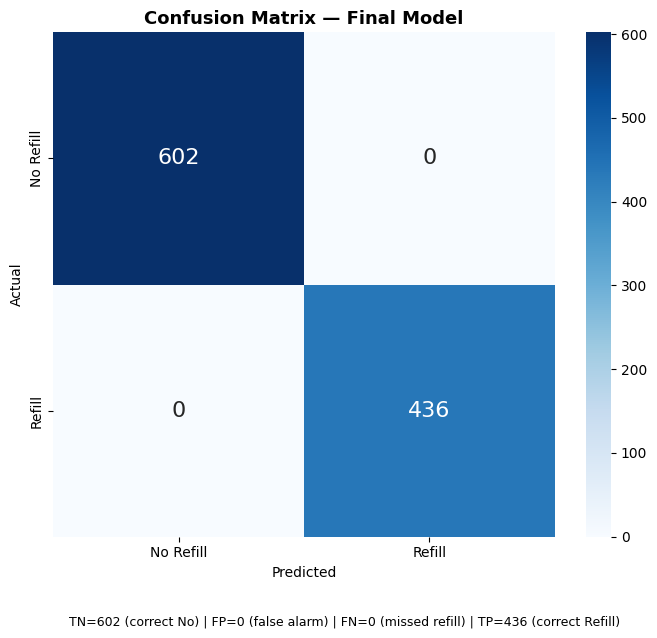

In [6]:
final_preds = best_model.predict(X_test)
final_proba = best_model.predict_proba(X_test)[:, 1]

print('=== FINAL MODEL PERFORMANCE ===')
print(classification_report(y_test, final_preds,
                             target_names=['No Refill', 'Refill']))
print(f'ROC-AUC : {roc_auc_score(y_test, final_proba):.4f}')

# Confusion Matrix
fig, ax = plt.subplots(figsize=(7, 6))
cm = confusion_matrix(y_test, final_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['No Refill','Refill'],
            yticklabels=['No Refill','Refill'],
            annot_kws={'size': 16})
ax.set_title('Confusion Matrix — Final Model', fontweight='bold', fontsize=13)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')

tn, fp, fn, tp = cm.ravel()
plt.figtext(0.5, -0.05,
    f'TN={tn} (correct No) | FP={fp} (false alarm) | FN={fn} (missed refill) | TP={tp} (correct Refill)',
    ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('../data/viz_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 6 — Save the Final Model

In [7]:
import pickle, json

# Save model
with open('../data/final_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

# Save feature list (needed at prediction time)
with open('../data/model_features.json', 'w') as f:
    json.dump(FEATURES, f)

# Save performance metrics
metrics = {
    'accuracy': float(accuracy_score(y_test, final_preds)),
    'f1_score': float(f1_score(y_test, final_preds)),
    'roc_auc':  float(roc_auc_score(y_test, final_proba)),
    'best_params': grid_search.best_params_
}
with open('../data/model_metrics.json', 'w') as f:
    json.dump(metrics, f, indent=2)

print('✅ Saved: data/final_model.pkl')
print('✅ Saved: data/model_features.json')
print('✅ Saved: data/model_metrics.json')
print(f'\nFinal model: Random Forest')
print(f'Accuracy   : {metrics["accuracy"]:.4f}')
print(f'F1 Score   : {metrics["f1_score"]:.4f}')
print(f'ROC-AUC    : {metrics["roc_auc"]:.4f}')

✅ Saved: data/final_model.pkl
✅ Saved: data/model_features.json
✅ Saved: data/model_metrics.json

Final model: Random Forest
Accuracy   : 1.0000
F1 Score   : 1.0000
ROC-AUC    : 1.0000
